# 15 ResNet-50 Baseline Dataset 2 (3 CNN Seeds)

This notebook runs three CNN seeds for the `baseline` experiment with `ResNet-50` under the `1 fold train + 4 folds test` protocol.


## Important Notes

- The CNN input size is locked at `224x224`.
- Every round uses one fold as train and the other four folds as test.
- This notebook saves checkpoints, predictions, metrics, summary tables, and figures.

- Each CNN seed is trained from a fresh model and saved in this notebook's final result folder.
- Running this notebook is allowed to overwrite the previous CNN result folder, because these are the finalised CNN results.


In [1]:
from pathlib import Path
import base64
import csv
import gc
import json
import os
import random
import shutil
import statistics
import subprocess
import sys
import tempfile
import time

import torch

from IPython.display import display
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

from tqdm.auto import tqdm

# This helper keeps the notebook easy to run from the repo root or from notebooks/.
def find_repo_root(start_path: Path) -> Path:
    if (start_path / "raw_data").exists():
        return start_path
    if start_path.name == "notebooks" and (start_path.parent / "raw_data").exists():
        return start_path.parent
    raise FileNotFoundError("Could not find the FYP2 repo root.")

REPO_ROOT = find_repo_root(Path.cwd())
MANIFESTS_DIR = REPO_ROOT / "manifests"
RESULTS_DIR = REPO_ROOT / "results"
CHECKPOINTS_DIR = REPO_ROOT / "checkpoints"
NOTEBOOK_TAG = "15_resnet50_baseline_dataset2"
NOTEBOOK_RESULTS_DIR = RESULTS_DIR / NOTEBOOK_TAG
NOTEBOOK_CHECKPOINTS_DIR = CHECKPOINTS_DIR / NOTEBOOK_TAG
NOTEBOOK_FIGURES_DIR = NOTEBOOK_RESULTS_DIR / "figures"

# This final CNN run is allowed to replace previous CNN outputs for this notebook only.
# Clearing only these folders prevents old single-seed files from mixing with final 3-seed outputs.
for output_dir in [NOTEBOOK_RESULTS_DIR, NOTEBOOK_CHECKPOINTS_DIR]:
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PATCH_MANIFEST_PATH = MANIFESTS_DIR / "dataset2_patch_manifest_224.csv"
GAN_MANIFEST_PATH = MANIFESTS_DIR / "dataset2_gan_generated_manifest_224.csv"
FOLD_MANIFEST_PATH = MANIFESTS_DIR / "dataset2_fold_manifest.csv"
MODEL_NAME = "resnet50"
MODEL_DISPLAY_NAME = "ResNet-50"
TRAINING_MODE = "baseline"
USE_GAN_IMAGES = False
CNN_SEEDS = [2026, 2027, 2028]
ROUNDS_TO_RUN = [1, 2, 3, 4, 5]
EPOCHS = 10
BATCH_SIZE = 16
NUM_WORKERS = 0
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE != "cuda":
    raise RuntimeError("CUDA is required for the main FYP runs. Please fix the GPU environment before running this notebook.")
torch.backends.cudnn.benchmark = True

print(f"Notebook tag: {NOTEBOOK_TAG}")
print(f"Model: {MODEL_DISPLAY_NAME}")
print(f"Training mode: {TRAINING_MODE}")
print(f"Use GAN images: {USE_GAN_IMAGES}")
print(f"CNN seeds: {CNN_SEEDS}")
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Notebook tag: 15_resnet50_baseline_dataset2
Model: ResNet-50
Training mode: baseline
Use GAN images: False
CNN seeds: [2026, 2027, 2028]
Device: cuda
GPU: NVIDIA GeForce RTX 4060


In [2]:
# This helper reads a CSV file into a plain list of rows.
def read_csv_rows(csv_path: Path):
    with csv_path.open("r", newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

# This helper writes a CSV file with a stable header.
def write_csv_rows(csv_path: Path, rows, fieldnames):
    if not rows:
        raise ValueError(f"No rows were provided for {csv_path.name}.")
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

# This helper writes one small JSON file with clean formatting.
def write_json(json_path: Path, data):
    json_path.parent.mkdir(parents=True, exist_ok=True)
    json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")

# This helper stores paths in repo-relative form so the outputs stay portable.
def as_repo_relative(repo_root: Path, path_value: Path) -> str:
    return path_value.relative_to(repo_root).as_posix()

# This helper keeps random choices repeatable.
def set_seed(seed_value: int):
    random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

# This helper keeps averages easy to read.
def average(values):
    return sum(values) / len(values) if values else 0.0

# This helper returns the sample standard deviation.
def sample_std(values):
    if len(values) <= 1:
        return 0.0
    return statistics.stdev(values)

# This helper avoids divide-by-zero problems in metric code.
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0

# This dataset returns one image, one label, and one row index.
# The row index lets us rebuild predictions with full metadata later.
class PatchDataset(Dataset):
    def __init__(self, rows, repo_root, image_transform):
        self.rows = rows
        self.repo_root = repo_root
        self.image_transform = image_transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]
        image_path = self.repo_root / row["file_path"]
        with Image.open(image_path) as image_handle:
            image = image_handle.convert("RGB")
        image = self.image_transform(image)
        label = torch.tensor(float(row["binary_label"]), dtype=torch.float32)
        return image, label, index

# This helper counts the two binary classes inside any row list.
def count_binary_groups(rows):
    cocci_count = sum(1 for row in rows if int(row["binary_label"]) == 0)
    bacilli_count = sum(1 for row in rows if int(row["binary_label"]) == 1)
    return cocci_count, bacilli_count

# This helper turns prediction rows into the binary metrics used in the report.
def compute_binary_metrics(prediction_rows):
    tp = sum(1 for row in prediction_rows if row["true_binary_label"] == 1 and row["predicted_binary_label"] == 1)
    tn = sum(1 for row in prediction_rows if row["true_binary_label"] == 0 and row["predicted_binary_label"] == 0)
    fp = sum(1 for row in prediction_rows if row["true_binary_label"] == 0 and row["predicted_binary_label"] == 1)
    fn = sum(1 for row in prediction_rows if row["true_binary_label"] == 1 and row["predicted_binary_label"] == 0)

    accuracy = safe_divide(tp + tn, tp + tn + fp + fn)
    precision_bacilli = safe_divide(tp, tp + fp)
    recall_bacilli = safe_divide(tp, tp + fn)
    precision_cocci = safe_divide(tn, tn + fn)
    recall_cocci = safe_divide(tn, tn + fp)
    macro_precision = (precision_cocci + precision_bacilli) / 2.0
    macro_recall = (recall_cocci + recall_bacilli) / 2.0
    balanced_accuracy = macro_recall
    f1_cocci = safe_divide(2 * precision_cocci * recall_cocci, precision_cocci + recall_cocci)
    f1_bacilli = safe_divide(2 * precision_bacilli * recall_bacilli, precision_bacilli + recall_bacilli)
    macro_f1 = (f1_cocci + f1_bacilli) / 2.0

    return {
        "sample_count": tp + tn + fp + fn,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "accuracy": round(accuracy, 6),
        "accuracy_cocci": round(recall_cocci, 6),
        "accuracy_bacilli": round(recall_bacilli, 6),
        "precision_cocci": round(precision_cocci, 6),
        "recall_cocci": round(recall_cocci, 6),
        "f1_cocci": round(f1_cocci, 6),
        "precision_bacilli": round(precision_bacilli, 6),
        "recall_bacilli": round(recall_bacilli, 6),
        "f1_bacilli": round(f1_bacilli, 6),
        "macro_precision": round(macro_precision, 6),
        "macro_recall": round(macro_recall, 6),
        "macro_f1": round(macro_f1, 6),
        "balanced_accuracy": round(balanced_accuracy, 6),
    }

# This helper expands confusion counts into explicit matrix rows.
def build_confusion_rows(metric_rows):
    confusion_rows = []
    for row in metric_rows:
        cocci_total = row["tn"] + row["fp"]
        bacilli_total = row["tp"] + row["fn"]
        cell_specs = [
            ("cocci", "cocci", row["tn"], safe_divide(row["tn"], cocci_total)),
            ("cocci", "bacilli", row["fp"], safe_divide(row["fp"], cocci_total)),
            ("bacilli", "cocci", row["fn"], safe_divide(row["fn"], bacilli_total)),
            ("bacilli", "bacilli", row["tp"], safe_divide(row["tp"], bacilli_total)),
        ]
        for true_class, predicted_class, count_value, row_rate in cell_specs:
            confusion_rows.append({
                "round_id": row["round_id"],
                "true_class": true_class,
                "predicted_class": predicted_class,
                "count": int(count_value),
                "row_rate": round(row_rate, 6),
            })
    return confusion_rows

# This helper builds one overall summary row from the round metrics.
def build_metric_summary(metric_rows):
    summary_row = {}
    metric_keys = [
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "precision_cocci",
        "recall_cocci",
        "f1_cocci",
        "precision_bacilli",
        "recall_bacilli",
        "f1_bacilli",
    ]
    for metric_key in metric_keys:
        values = [float(row[metric_key]) for row in metric_rows]
        summary_row[f"mean_{metric_key}"] = round(average(values), 6)
        summary_row[f"std_{metric_key}"] = round(sample_std(values), 6)
    return summary_row

# This helper runs one epoch and keeps the code short and plain.
def run_one_epoch(model, data_loader, criterion, device, optimizer=None):
    is_training = optimizer is not None
    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0
    total_correct = 0

    for images, labels, _ in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(is_training):
            logits = model(images).view(-1)
            loss = criterion(logits, labels)
            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        label_ints = labels.to(torch.int64)
        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        total_correct += (predictions == label_ints).sum().item()

    return {
        "loss": safe_divide(total_loss, total_samples),
        "accuracy": safe_divide(total_correct, total_samples),
    }

# This helper runs the final test pass and keeps every prediction row for traceability.
def evaluate_model(model, data_loader, row_lookup):
    model.eval()
    prediction_rows = []
    with torch.no_grad():
        for images, labels, indices in data_loader:
            images = images.to(DEVICE)
            logits = model(images).view(-1)
            probabilities = torch.sigmoid(logits).cpu().tolist()
            labels_list = labels.to(torch.int64).cpu().tolist()
            index_list = indices.cpu().tolist()

            for batch_index, row_index in enumerate(index_list):
                source_row = row_lookup[row_index]
                true_label = int(labels_list[batch_index])
                predicted_label = 1 if probabilities[batch_index] >= 0.5 else 0
                prediction_rows.append({
                    "round_id": source_row["round_id"],
                    "train_fold_id": source_row["train_fold_id"],
                    "test_fold_ids": source_row["test_fold_ids"],
                    "sample_id": source_row["sample_id"],
                    "raw_sample_id": source_row["raw_sample_id"],
                    "species_name": source_row["species_name"],
                    "true_binary_label": true_label,
                    "true_binary_group": "bacilli" if true_label == 1 else "cocci",
                    "predicted_probability_bacilli": round(probabilities[batch_index], 6),
                    "predicted_binary_label": predicted_label,
                    "predicted_binary_group": "bacilli" if predicted_label == 1 else "cocci",
                    "source_type": source_row["source_type"],
                    "file_path": source_row["file_path"],
                })
    metric_row = compute_binary_metrics(prediction_rows)
    return prediction_rows, metric_row

# This helper keeps the three backbones in one small place.
def build_model(model_name: str):
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = torch.nn.Linear(model.fc.in_features, 1)
        return model
    if model_name == "efficientnetv2s":
        model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 1)
        return model
    if model_name == "convnextv2nano":
        try:
            import timm
        except ImportError as error:
            raise ImportError("Please install timm in the active environment before running this notebook.") from error
        return timm.create_model("convnextv2_nano.fcmae_ft_in22k_in1k", pretrained=True, num_classes=1)
    raise ValueError(f"Unknown model name: {model_name}")

In [3]:
# We load the saved manifests and build the round-specific train and test row lists.
real_patch_rows = read_csv_rows(PATCH_MANIFEST_PATH)
fold_manifest_rows = read_csv_rows(FOLD_MANIFEST_PATH)
for row in real_patch_rows:
    row["fold_id"] = int(row["fold_id"])
    row["binary_label"] = int(row["binary_label"])
for row in fold_manifest_rows:
    row["fold_id"] = int(row["fold_id"])
    row["binary_label"] = int(row["binary_label"])

generated_rows = []
if USE_GAN_IMAGES:
    if not GAN_MANIFEST_PATH.exists():
        raise FileNotFoundError(f"Missing GAN manifest: {GAN_MANIFEST_PATH}. Please run the paired GAN notebook first.")
    generated_rows = read_csv_rows(GAN_MANIFEST_PATH)
    for row in generated_rows:
        row["fold_id"] = int(row["fold_id"])
        row["binary_label"] = int(row["binary_label"])

round_train_rows_lookup = {}
round_test_rows_lookup = {}
round_plan_rows = []

for round_id in ROUNDS_TO_RUN:
    train_fold_id = round_id
    test_fold_ids = [fold_id for fold_id in ROUNDS_TO_RUN if fold_id != train_fold_id]
    test_fold_text = ",".join(str(value) for value in test_fold_ids)

    real_train_rows = []
    test_rows = []
    gan_train_rows = []

    for row in real_patch_rows:
        prepared_row = {
            "round_id": round_id,
            "train_fold_id": train_fold_id,
            "test_fold_ids": test_fold_text,
            "sample_id": row["patch_id"],
            "raw_sample_id": row["image_id"],
            "species_name": row["species_name"],
            "binary_label": int(row["binary_label"]),
            "binary_group": row["binary_group"],
            "file_path": row["file_path"],
            "source_type": row["source_type"],
        }
        if int(row["fold_id"]) == train_fold_id:
            real_train_rows.append(prepared_row)
        elif int(row["fold_id"]) in test_fold_ids:
            test_rows.append(prepared_row)

    for row in generated_rows:
        if int(row["fold_id"]) != train_fold_id:
            continue
        gan_train_rows.append({
            "round_id": round_id,
            "train_fold_id": train_fold_id,
            "test_fold_ids": test_fold_text,
            "sample_id": row["gan_image_id"],
            "raw_sample_id": row["gan_image_id"],
            "species_name": "synthetic_cocci",
            "binary_label": int(row["binary_label"]),
            "binary_group": row["binary_group"],
            "file_path": row["file_path"],
            "source_type": row["source_type"],
        })

    if not real_train_rows:
        raise ValueError(f"Round {round_id} has no real train rows.")
    if not test_rows:
        raise ValueError(f"Round {round_id} has no test rows.")
    if USE_GAN_IMAGES and not gan_train_rows:
        raise ValueError(f"Round {round_id} has no generated train rows.")

    train_rows = list(real_train_rows) + list(gan_train_rows)
    train_raw_ids = {row["raw_sample_id"] for row in real_train_rows}
    test_raw_ids = {row["raw_sample_id"] for row in test_rows}
    overlap_raw_ids = sorted(train_raw_ids.intersection(test_raw_ids))
    if overlap_raw_ids:
        raise AssertionError(
            f"Raw-sample leakage was found in round {round_id}. Example overlap: {overlap_raw_ids[:3]}"
        )

    real_train_cocci_count, real_train_bacilli_count = count_binary_groups(real_train_rows)
    test_cocci_count, test_bacilli_count = count_binary_groups(test_rows)
    gan_train_cocci_count, gan_train_bacilli_count = count_binary_groups(gan_train_rows)
    train_cocci_count, train_bacilli_count = count_binary_groups(train_rows)

    raw_train_sample_count = sum(1 for row in fold_manifest_rows if int(row["fold_id"]) == train_fold_id)
    raw_test_sample_count = sum(1 for row in fold_manifest_rows if int(row["fold_id"]) in test_fold_ids)

    round_train_rows_lookup[round_id] = train_rows
    round_test_rows_lookup[round_id] = test_rows
    round_plan_rows.append({
        "round_id": round_id,
        "train_fold_id": train_fold_id,
        "test_fold_ids": test_fold_text,
        "raw_train_sample_count": raw_train_sample_count,
        "raw_test_sample_count": raw_test_sample_count,
        "real_train_patch_count": len(real_train_rows),
        "gan_train_patch_count": len(gan_train_rows),
        "total_train_patch_count": len(train_rows),
        "test_patch_count": len(test_rows),
        "real_train_cocci_count": real_train_cocci_count,
        "real_train_bacilli_count": real_train_bacilli_count,
        "gan_train_cocci_count": gan_train_cocci_count,
        "gan_train_bacilli_count": gan_train_bacilli_count,
        "train_cocci_count": train_cocci_count,
        "train_bacilli_count": train_bacilli_count,
        "test_cocci_count": test_cocci_count,
        "test_bacilli_count": test_bacilli_count,
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "round_plan.csv", round_plan_rows, list(round_plan_rows[0].keys()))
display(round_plan_rows)

[{'round_id': 1,
  'train_fold_id': 1,
  'test_fold_ids': '2,3,4,5',
  'raw_train_sample_count': 86,
  'raw_test_sample_count': 341,
  'real_train_patch_count': 870,
  'gan_train_patch_count': 0,
  'total_train_patch_count': 870,
  'test_patch_count': 3309,
  'real_train_cocci_count': 380,
  'real_train_bacilli_count': 490,
  'gan_train_cocci_count': 0,
  'gan_train_bacilli_count': 0,
  'train_cocci_count': 380,
  'train_bacilli_count': 490,
  'test_cocci_count': 1407,
  'test_bacilli_count': 1902},
 {'round_id': 2,
  'train_fold_id': 2,
  'test_fold_ids': '1,3,4,5',
  'raw_train_sample_count': 86,
  'raw_test_sample_count': 341,
  'real_train_patch_count': 837,
  'gan_train_patch_count': 0,
  'total_train_patch_count': 837,
  'test_patch_count': 3342,
  'real_train_cocci_count': 344,
  'real_train_bacilli_count': 493,
  'gan_train_cocci_count': 0,
  'gan_train_bacilli_count': 0,
  'train_cocci_count': 344,
  'train_bacilli_count': 493,
  'test_cocci_count': 1443,
  'test_bacilli_count

In [4]:
# We train each CNN seed from a fresh model, then test each fold and save the outputs immediately.
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
criterion = torch.nn.BCEWithLogitsLoss()

for cnn_seed in CNN_SEEDS:
    for round_id in ROUNDS_TO_RUN:
        # Keep the same CNN seed across folds so the three repeats are easy to audit.
        run_seed = cnn_seed
        print(f"\nStarting seed {cnn_seed}, round {round_id}")
        set_seed(run_seed)
        torch.cuda.empty_cache()
        gc.collect()

        train_rows = round_train_rows_lookup[round_id]
        test_rows = round_test_rows_lookup[round_id]
        train_dataset = PatchDataset(train_rows, REPO_ROOT, image_transform)
        test_dataset = PatchDataset(test_rows, REPO_ROOT, image_transform)
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            generator=torch.Generator().manual_seed(run_seed),
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
        )

        model = build_model(MODEL_NAME).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        round_start_time = time.time()
        round_history_rows = []

        epoch_bar = tqdm(range(1, EPOCHS + 1), desc=f"seed {cnn_seed} round {round_id}", leave=True)
        for epoch in epoch_bar:
            train_metrics = run_one_epoch(model, train_loader, criterion, DEVICE, optimizer=optimizer)
            elapsed_seconds = round(time.time() - round_start_time, 2)
            epoch_bar.set_postfix(loss=f"{train_metrics['loss']:.4f}", acc=f"{train_metrics['accuracy']:.4f}")
            round_history_rows.append({
                "cnn_seed": cnn_seed,
                "run_seed": run_seed,
                "round_id": round_id,
                "epoch": epoch,
                "train_loss": round(train_metrics["loss"], 6),
                "train_accuracy": round(train_metrics["accuracy"], 6),
                "elapsed_seconds": elapsed_seconds,
            })

        prediction_rows, metric_row = evaluate_model(model, test_loader, test_rows)
        for prediction_row in prediction_rows:
            prediction_row["cnn_seed"] = cnn_seed
            prediction_row["run_seed"] = run_seed

        round_elapsed_seconds = round(time.time() - round_start_time, 2)
        final_train_row = round_history_rows[-1]
        round_plan_row = next(row for row in round_plan_rows if int(row["round_id"]) == round_id)

        checkpoint_path = NOTEBOOK_CHECKPOINTS_DIR / f"seed_{cnn_seed}_round_{round_id}_final.pth"
        prediction_path = NOTEBOOK_RESULTS_DIR / f"seed_{cnn_seed}_round_{round_id}_predictions.csv"
        history_path = NOTEBOOK_RESULTS_DIR / f"seed_{cnn_seed}_round_{round_id}_training_history.csv"
        metrics_json_path = NOTEBOOK_RESULTS_DIR / f"seed_{cnn_seed}_round_{round_id}_metrics.json"

        torch.save({
            "notebook_tag": NOTEBOOK_TAG,
            "model_name": MODEL_NAME,
            "model_display_name": MODEL_DISPLAY_NAME,
            "training_mode": TRAINING_MODE,
            "cnn_seed": cnn_seed,
            "run_seed": run_seed,
            "round_id": round_id,
            "epochs": EPOCHS,
            "state_dict": model.state_dict(),
        }, checkpoint_path)

        write_csv_rows(history_path, round_history_rows, list(round_history_rows[0].keys()))
        write_csv_rows(prediction_path, prediction_rows, list(prediction_rows[0].keys()))

        round_metric_row = {
            "cnn_seed": cnn_seed,
            "run_seed": run_seed,
            "round_id": round_id,
            "model_name": MODEL_NAME,
            "model_display_name": MODEL_DISPLAY_NAME,
            "training_mode": TRAINING_MODE,
            "epochs": EPOCHS,
            "train_loss_final": final_train_row["train_loss"],
            "train_accuracy_final": final_train_row["train_accuracy"],
            "elapsed_seconds": round_elapsed_seconds,
            **round_plan_row,
            **metric_row,
            "checkpoint_path": as_repo_relative(REPO_ROOT, checkpoint_path),
            "prediction_path": as_repo_relative(REPO_ROOT, prediction_path),
            "training_history_path": as_repo_relative(REPO_ROOT, history_path),
        }
        write_json(metrics_json_path, round_metric_row)
        print(
            f"seed {cnn_seed}, round {round_id} done | acc={round_metric_row['accuracy']:.4f} | "
            f"macro_f1={round_metric_row['macro_f1']:.4f} | elapsed={round_elapsed_seconds:.2f}s"
        )

        del model, optimizer, train_loader, test_loader, train_dataset, test_dataset
        torch.cuda.empty_cache()
        gc.collect()


Starting seed 2026, round 1


seed 2026 round 1:   0%|          | 0/10 [00:00<?, ?it/s]

seed 2026, round 1 done | acc=0.9924 | macro_f1=0.9923 | elapsed=129.93s

Starting seed 2026, round 2


seed 2026 round 2:   0%|          | 0/10 [00:00<?, ?it/s]

seed 2026, round 2 done | acc=0.9895 | macro_f1=0.9893 | elapsed=106.71s

Starting seed 2026, round 3


...

seed 2028, round 3 done | acc=0.9929 | macro_f1=0.9927 | elapsed=76.79s

Starting seed 2028, round 4


seed 2028 round 4:   0%|          | 0/10 [00:00<?, ?it/s]

seed 2028, round 4 done | acc=0.9887 | macro_f1=0.9885 | elapsed=78.52s

Starting seed 2028, round 5


seed 2028 round 5:   0%|          | 0/10 [00:00<?, ?it/s]

seed 2028, round 5 done | acc=0.9952 | macro_f1=0.9951 | elapsed=79.59s


Saved 3-seed summary tables and figures to: C:\Users\FYP2610\Downloads\FYP2\results\15_resnet50_baseline_dataset2


[{'cnn_seed': '2026',
  'run_seed': '2026',
  'round_id': '1',
  'model_name': 'resnet50',
  'model_display_name': 'ResNet-50',
  'training_mode': 'baseline',
  'epochs': '10',
  'train_loss_final': '0.002855',
  'train_accuracy_final': '1.0',
  'elapsed_seconds': '129.93',
  'train_fold_id': '1',
  'test_fold_ids': '2,3,4,5',
  'raw_train_sample_count': '86',
  'raw_test_sample_count': '341',
  'real_train_patch_count': '870',
  'gan_train_patch_count': '0',
  'total_train_patch_count': '870',
  'test_patch_count': '3309',
  'real_train_cocci_count': '380',
  'real_train_bacilli_count': '490',
  'gan_train_cocci_count': '0',
  'gan_train_bacilli_count': '0',
  'train_cocci_count': '380',
  'train_bacilli_count': '490',
  'test_cocci_count': '1407',
  'test_bacilli_count': '1902',
  'sample_count': '3309',
  'tp': '1884',
  'tn': '1400',
  'fp': '7',
  'fn': '18',
  'accuracy': '0.992445',
  'accuracy_cocci': '0.995025',
  'accuracy_bacilli': '0.990536',
  'precision_cocci': '0.987306'

[{'seed_count': '3',
  'fold_count': '5',
  'run_count': '15',
  'mean_accuracy': '0.991274',
  'std_accuracy': '0.003467',
  'mean_balanced_accuracy': '0.991482',
  'std_balanced_accuracy': '0.002911',
  'mean_macro_precision': '0.990785',
  'std_macro_precision': '0.004098',
  'mean_macro_recall': '0.991482',
  'std_macro_recall': '0.002911',
  'mean_macro_f1': '0.9911',
  'std_macro_f1': '0.003519'}]

[{'class_name': 'cocci',
  'mean_precision': '0.986845',
  'std_precision': '0.009519',
  'mean_recall': '0.99295',
  'std_recall': '0.003397',
  'mean_f1': '0.989854',
  'std_f1': '0.003953'},
 {'class_name': 'bacilli',
  'mean_precision': '0.994726',
  'std_precision': '0.002505',
  'mean_recall': '0.990014',
  'std_recall': '0.007343',
  'mean_f1': '0.992345',
  'std_f1': '0.003086'}]

[{'cnn_seed': '2026',
  'fold_count': '5',
  'mean_accuracy': '0.990317',
  'std_accuracy': '0.005074',
  'mean_balanced_accuracy': '0.990554',
  'std_balanced_accuracy': '0.004375',
  'mean_macro_f1': '0.990126',
  'std_macro_f1': '0.005152'},
 {'cnn_seed': '2027',
  'fold_count': '5',
  'mean_accuracy': '0.991333',
  'std_accuracy': '0.001687',
  'mean_balanced_accuracy': '0.99143',
  'std_balanced_accuracy': '0.001094',
  'mean_macro_f1': '0.991154',
  'std_macro_f1': '0.001709'},
 {'cnn_seed': '2028',
  'fold_count': '5',
  'mean_accuracy': '0.992173',
  'std_accuracy': '0.003363',
  'mean_balanced_accuracy': '0.992463',
  'std_balanced_accuracy': '0.002654',
  'mean_macro_f1': '0.992019',
  'std_macro_f1': '0.003411'}]

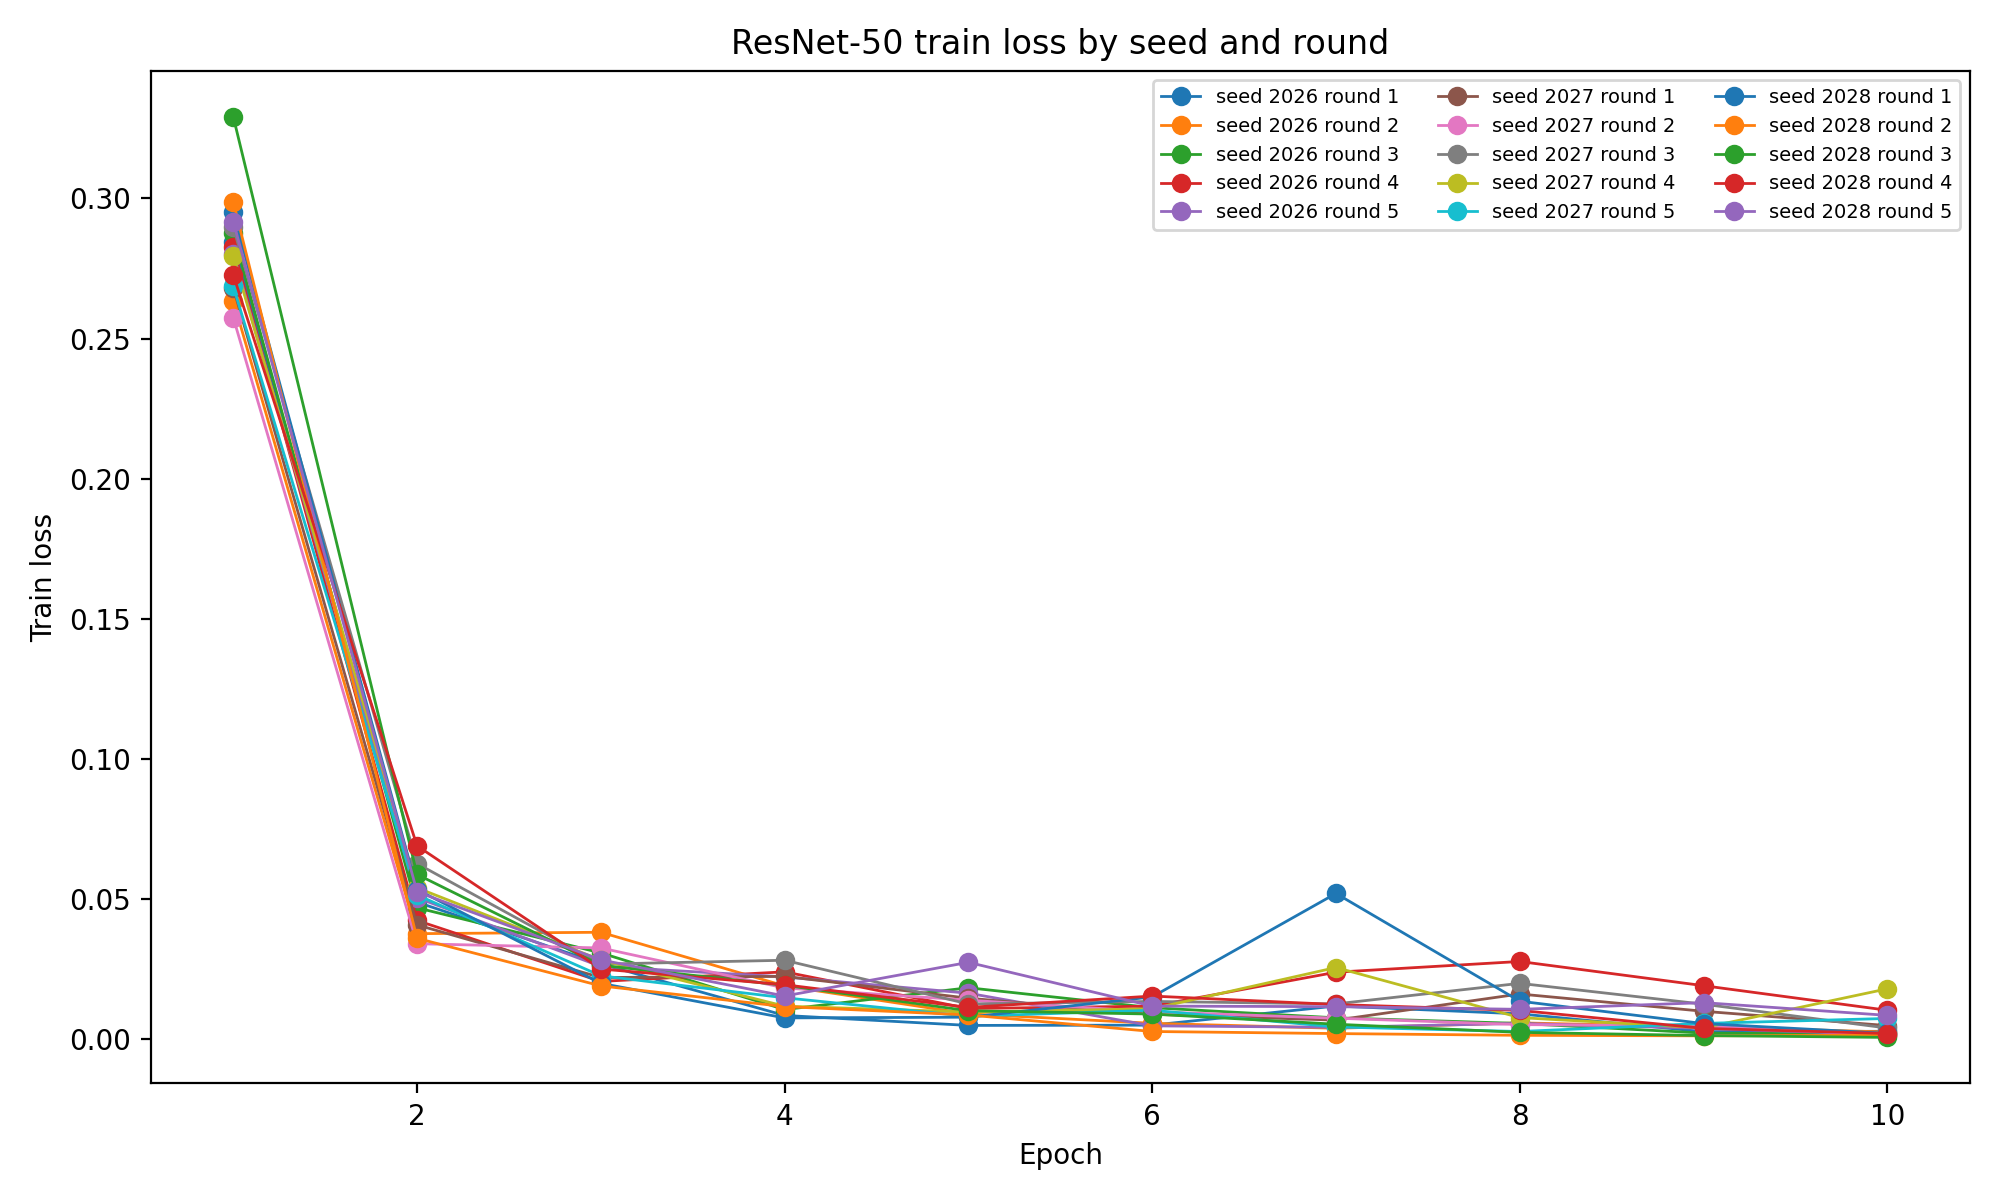

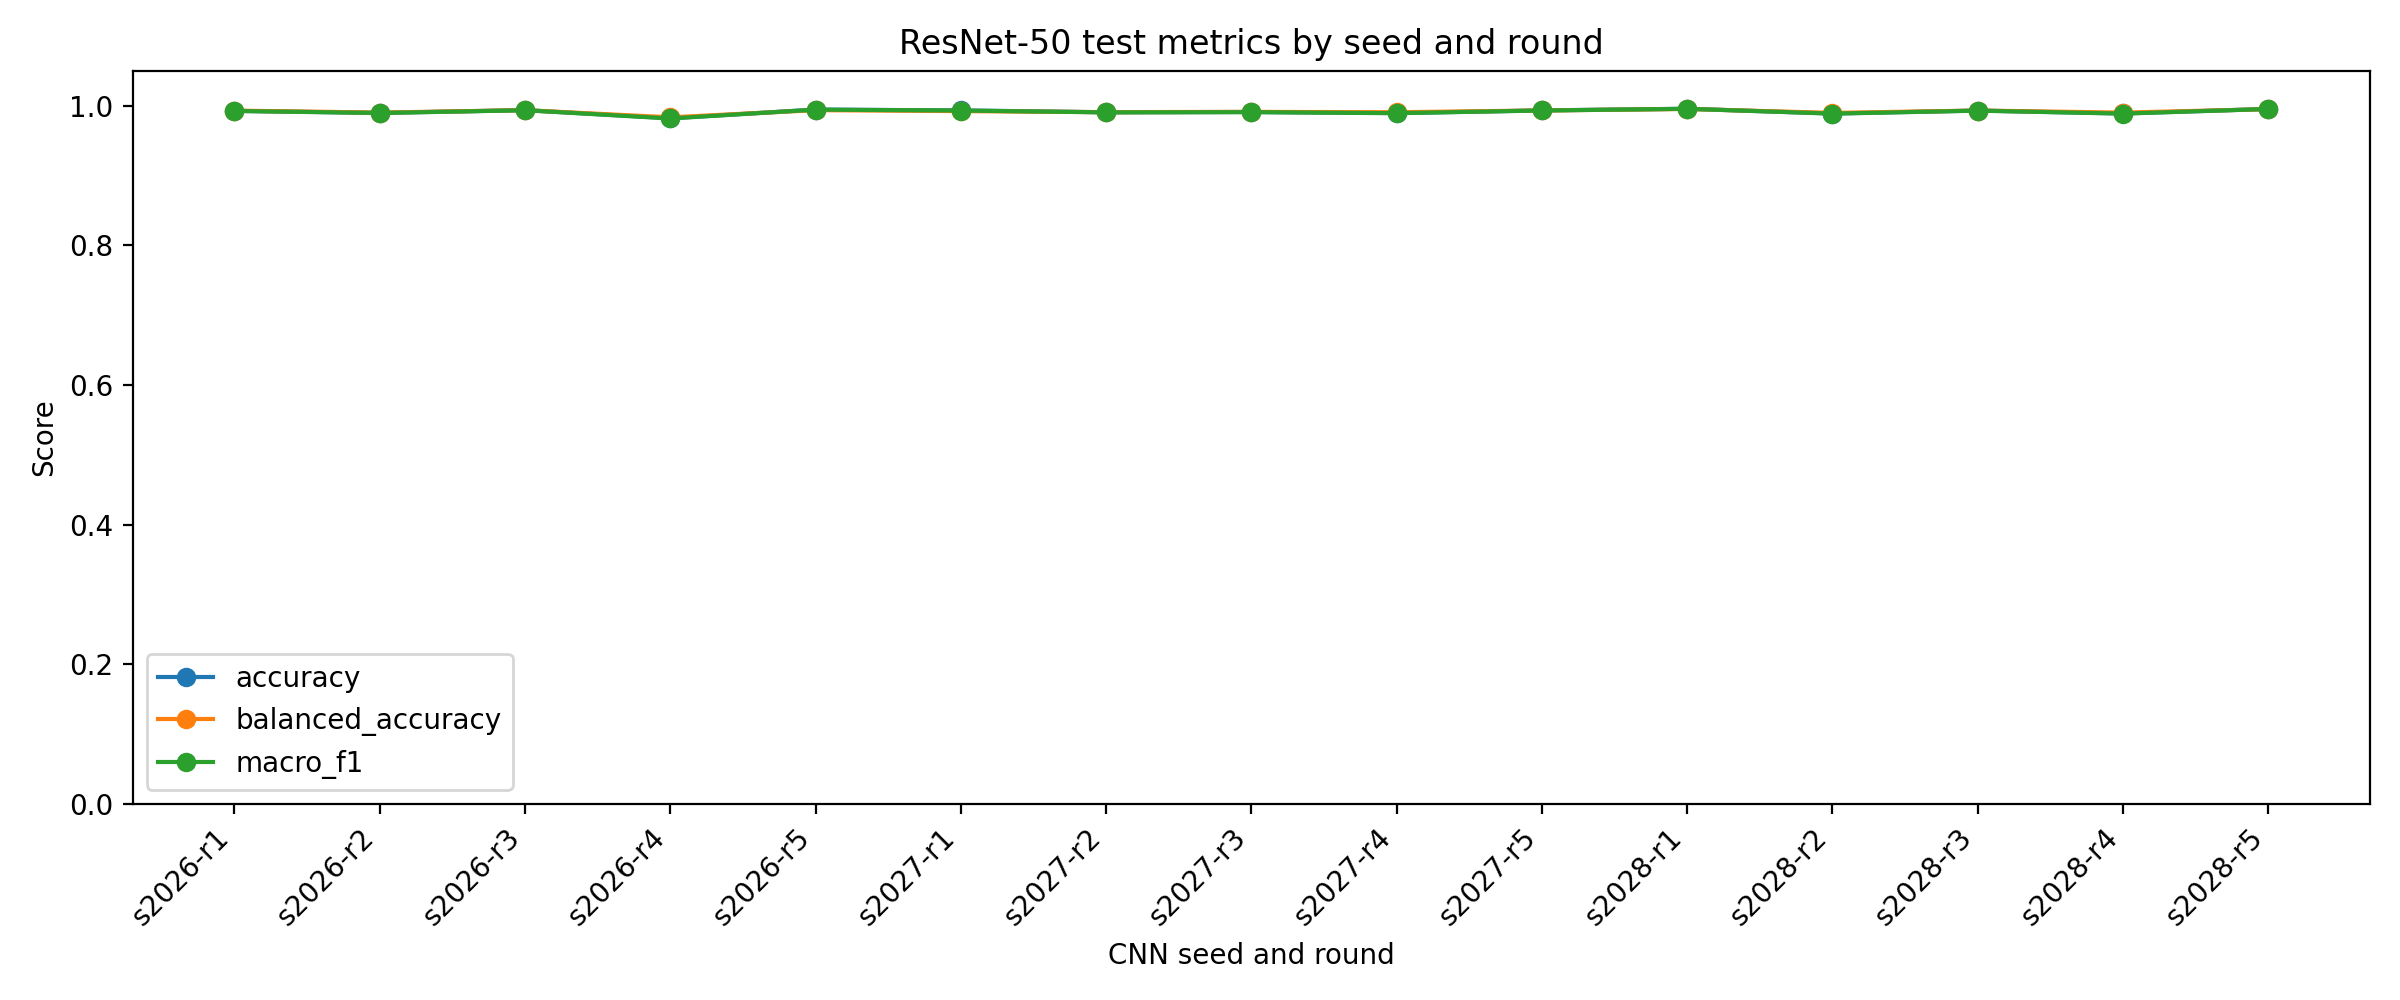

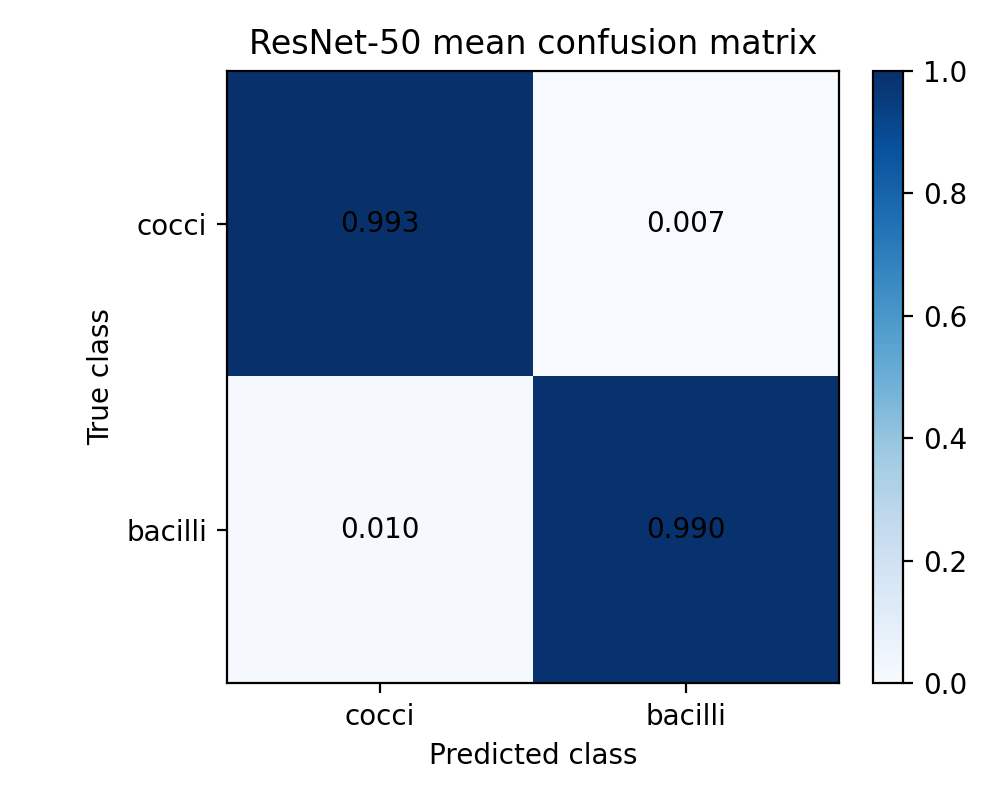

In [5]:
# We build the summary in a clean Python process so Windows does not mix Torch with the plotting stack.
summary_config = {
    "results_dir": str(NOTEBOOK_RESULTS_DIR),
    "figures_dir": str(NOTEBOOK_FIGURES_DIR),
    "checkpoints_dir_value": as_repo_relative(REPO_ROOT, NOTEBOOK_CHECKPOINTS_DIR),
    "figures_dir_value": as_repo_relative(REPO_ROOT, NOTEBOOK_FIGURES_DIR),
    "notebook_tag": NOTEBOOK_TAG,
    "model_name": MODEL_NAME,
    "model_display_name": MODEL_DISPLAY_NAME,
    "training_mode": TRAINING_MODE,
    "use_gan_images": USE_GAN_IMAGES,
    "cnn_seeds": CNN_SEEDS,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "round_ids": ROUNDS_TO_RUN,
    "patch_manifest_path": as_repo_relative(REPO_ROOT, PATCH_MANIFEST_PATH),
    "gan_manifest_path": as_repo_relative(REPO_ROOT, GAN_MANIFEST_PATH) if USE_GAN_IMAGES else "",
    "fold_manifest_path": as_repo_relative(REPO_ROOT, FOLD_MANIFEST_PATH),
}

summary_script = '''
from pathlib import Path
import base64
import csv
import json
import statistics

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

summary_config = json.loads(base64.b64decode("__SUMMARY_CONFIG_BASE64__").decode("utf-8"))
results_dir = Path(summary_config["results_dir"])
figures_dir = Path(summary_config["figures_dir"])
cnn_seeds = [int(value) for value in summary_config["cnn_seeds"]]
round_ids = [int(value) for value in summary_config["round_ids"]]


def read_csv_rows(csv_path: Path):
    with csv_path.open("r", newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))


def write_csv_rows(csv_path: Path, rows, fieldnames):
    if not rows:
        raise ValueError(f"No rows were provided for {csv_path.name}.")
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def write_json(json_path: Path, data):
    json_path.parent.mkdir(parents=True, exist_ok=True)
    json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def average(values):
    return sum(values) / len(values) if values else 0.0


def sample_std(values):
    if len(values) <= 1:
        return 0.0
    return statistics.stdev(values)


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def build_confusion_rows(metric_rows):
    confusion_rows = []
    for row in metric_rows:
        cocci_total = row["tn"] + row["fp"]
        bacilli_total = row["tp"] + row["fn"]
        cell_specs = [
            ("cocci", "cocci", row["tn"], safe_divide(row["tn"], cocci_total)),
            ("cocci", "bacilli", row["fp"], safe_divide(row["fp"], cocci_total)),
            ("bacilli", "cocci", row["fn"], safe_divide(row["fn"], bacilli_total)),
            ("bacilli", "bacilli", row["tp"], safe_divide(row["tp"], bacilli_total)),
        ]
        for true_class, predicted_class, count_value, row_rate in cell_specs:
            confusion_rows.append({
                "cnn_seed": row["cnn_seed"],
                "run_seed": row["run_seed"],
                "round_id": row["round_id"],
                "true_class": true_class,
                "predicted_class": predicted_class,
                "count": int(count_value),
                "row_rate": round(row_rate, 6),
            })
    return confusion_rows


def build_metric_summary(metric_rows):
    summary_row = {}
    metric_keys = [
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "precision_cocci",
        "recall_cocci",
        "f1_cocci",
        "precision_bacilli",
        "recall_bacilli",
        "f1_bacilli",
    ]
    for metric_key in metric_keys:
        values = [float(row[metric_key]) for row in metric_rows]
        summary_row[f"mean_{metric_key}"] = round(average(values), 6)
        summary_row[f"std_{metric_key}"] = round(sample_std(values), 6)
    return summary_row


round_metric_rows = []
history_rows = []
prediction_rows = []

for cnn_seed in cnn_seeds:
    for round_id in round_ids:
        metrics_json_path = results_dir / f"seed_{cnn_seed}_round_{round_id}_metrics.json"
        history_path = results_dir / f"seed_{cnn_seed}_round_{round_id}_training_history.csv"
        prediction_path = results_dir / f"seed_{cnn_seed}_round_{round_id}_predictions.csv"

        metric_row = json.loads(metrics_json_path.read_text(encoding="utf-8"))
        metric_row["cnn_seed"] = int(metric_row["cnn_seed"])
        metric_row["run_seed"] = int(metric_row["run_seed"])
        metric_row["round_id"] = int(metric_row["round_id"])
        for key in ["tp", "tn", "fp", "fn", "sample_count"]:
            metric_row[key] = int(metric_row[key])
        for key in [
            "accuracy",
            "balanced_accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "precision_cocci",
            "recall_cocci",
            "f1_cocci",
            "precision_bacilli",
            "recall_bacilli",
            "f1_bacilli",
        ]:
            metric_row[key] = float(metric_row[key])
        round_metric_rows.append(metric_row)

        current_history_rows = read_csv_rows(history_path)
        for row in current_history_rows:
            row["cnn_seed"] = int(row["cnn_seed"])
            row["run_seed"] = int(row["run_seed"])
            row["round_id"] = int(row["round_id"])
            row["epoch"] = int(row["epoch"])
            row["train_loss"] = float(row["train_loss"])
            row["train_accuracy"] = float(row["train_accuracy"])
            row["elapsed_seconds"] = float(row["elapsed_seconds"])
        history_rows.extend(current_history_rows)

        current_prediction_rows = read_csv_rows(prediction_path)
        for row in current_prediction_rows:
            row["cnn_seed"] = int(row["cnn_seed"])
            row["run_seed"] = int(row["run_seed"])
            row["round_id"] = int(row["round_id"])
            row["true_binary_label"] = int(row["true_binary_label"])
            row["predicted_probability_bacilli"] = float(row["predicted_probability_bacilli"])
            row["predicted_binary_label"] = int(row["predicted_binary_label"])
        prediction_rows.extend(current_prediction_rows)

round_metric_rows = sorted(round_metric_rows, key=lambda row: (row["cnn_seed"], row["round_id"]))
history_rows = sorted(history_rows, key=lambda row: (row["cnn_seed"], row["round_id"], row["epoch"]))
prediction_rows = sorted(prediction_rows, key=lambda row: (row["cnn_seed"], row["round_id"], row["sample_id"]))

write_csv_rows(results_dir / "round_metrics.csv", round_metric_rows, list(round_metric_rows[0].keys()))
write_csv_rows(results_dir / "training_history.csv", history_rows, list(history_rows[0].keys()))
write_csv_rows(results_dir / "all_predictions.csv", prediction_rows, list(prediction_rows[0].keys()))

summary_row = build_metric_summary(round_metric_rows)
overall_rows = [{
    "seed_count": len(cnn_seeds),
    "fold_count": len(round_ids),
    "run_count": len(round_metric_rows),
    "mean_accuracy": summary_row["mean_accuracy"],
    "std_accuracy": summary_row["std_accuracy"],
    "mean_balanced_accuracy": summary_row["mean_balanced_accuracy"],
    "std_balanced_accuracy": summary_row["std_balanced_accuracy"],
    "mean_macro_precision": summary_row["mean_macro_precision"],
    "std_macro_precision": summary_row["std_macro_precision"],
    "mean_macro_recall": summary_row["mean_macro_recall"],
    "std_macro_recall": summary_row["std_macro_recall"],
    "mean_macro_f1": summary_row["mean_macro_f1"],
    "std_macro_f1": summary_row["std_macro_f1"],
}]
write_csv_rows(results_dir / "overall_metrics_mean.csv", overall_rows, list(overall_rows[0].keys()))

class_rows = [
    {
        "class_name": "cocci",
        "mean_precision": summary_row["mean_precision_cocci"],
        "std_precision": summary_row["std_precision_cocci"],
        "mean_recall": summary_row["mean_recall_cocci"],
        "std_recall": summary_row["std_recall_cocci"],
        "mean_f1": summary_row["mean_f1_cocci"],
        "std_f1": summary_row["std_f1_cocci"],
    },
    {
        "class_name": "bacilli",
        "mean_precision": summary_row["mean_precision_bacilli"],
        "std_precision": summary_row["std_precision_bacilli"],
        "mean_recall": summary_row["mean_recall_bacilli"],
        "std_recall": summary_row["std_recall_bacilli"],
        "mean_f1": summary_row["mean_f1_bacilli"],
        "std_f1": summary_row["std_f1_bacilli"],
    },
]
write_csv_rows(results_dir / "class_metrics_mean.csv", class_rows, list(class_rows[0].keys()))

seed_summary_rows = []
for cnn_seed in cnn_seeds:
    current_rows = [row for row in round_metric_rows if int(row["cnn_seed"]) == cnn_seed]
    current_summary = build_metric_summary(current_rows)
    seed_summary_rows.append({
        "cnn_seed": cnn_seed,
        "fold_count": len(current_rows),
        "mean_accuracy": current_summary["mean_accuracy"],
        "std_accuracy": current_summary["std_accuracy"],
        "mean_balanced_accuracy": current_summary["mean_balanced_accuracy"],
        "std_balanced_accuracy": current_summary["std_balanced_accuracy"],
        "mean_macro_f1": current_summary["mean_macro_f1"],
        "std_macro_f1": current_summary["std_macro_f1"],
    })
write_csv_rows(results_dir / "seed_metrics_mean.csv", seed_summary_rows, list(seed_summary_rows[0].keys()))


confusion_rows = build_confusion_rows(round_metric_rows)
write_csv_rows(results_dir / "round_confusion_matrices.csv", confusion_rows, list(confusion_rows[0].keys()))
mean_confusion_rows = []
for true_class in ["cocci", "bacilli"]:
    for predicted_class in ["cocci", "bacilli"]:
        row_rates = [
            float(row["row_rate"])
            for row in confusion_rows
            if row["true_class"] == true_class and row["predicted_class"] == predicted_class
        ]
        mean_confusion_rows.append({
            "true_class": true_class,
            "predicted_class": predicted_class,
            "mean_row_rate": round(average(row_rates), 6),
            "std_row_rate": round(sample_std(row_rates), 6),
        })
write_csv_rows(results_dir / "confusion_matrix_mean.csv", mean_confusion_rows, list(mean_confusion_rows[0].keys()))

write_json(
    results_dir / "summary.json",
    {
        "notebook_tag": summary_config["notebook_tag"],
        "model_name": summary_config["model_name"],
        "model_display_name": summary_config["model_display_name"],
        "training_mode": summary_config["training_mode"],
        "use_gan_images": bool(summary_config["use_gan_images"]),
        "cnn_seeds": cnn_seeds,
        "seed_count": len(cnn_seeds),
        "fold_count": len(round_ids),
        "run_count": len(round_metric_rows),
        "epochs": summary_config["epochs"],
        "batch_size": summary_config["batch_size"],
        "learning_rate": summary_config["learning_rate"],
        "weight_decay": summary_config["weight_decay"],
        "patch_manifest_path": summary_config["patch_manifest_path"],
        "gan_manifest_path": summary_config["gan_manifest_path"],
        "fold_manifest_path": summary_config["fold_manifest_path"],
        "mean_accuracy": summary_row["mean_accuracy"],
        "std_accuracy": summary_row["std_accuracy"],
        "mean_balanced_accuracy": summary_row["mean_balanced_accuracy"],
        "std_balanced_accuracy": summary_row["std_balanced_accuracy"],
        "mean_macro_precision": summary_row["mean_macro_precision"],
        "std_macro_precision": summary_row["std_macro_precision"],
        "mean_macro_recall": summary_row["mean_macro_recall"],
        "std_macro_recall": summary_row["std_macro_recall"],
        "mean_macro_f1": summary_row["mean_macro_f1"],
        "std_macro_f1": summary_row["std_macro_f1"],
        "checkpoints_dir": summary_config["checkpoints_dir_value"],
        "figures_dir": summary_config["figures_dir_value"],
    },
)

history_by_run = {}
for row in history_rows:
    history_by_run.setdefault((int(row["cnn_seed"]), int(row["round_id"])), []).append(row)

fig, axis = plt.subplots(figsize=(10, 6))
for cnn_seed, round_id in sorted(history_by_run):
    current_rows = sorted(history_by_run[(cnn_seed, round_id)], key=lambda row: row["epoch"])
    axis.plot(
        [row["epoch"] for row in current_rows],
        [row["train_loss"] for row in current_rows],
        marker="o",
        linewidth=1,
        label=f"seed {cnn_seed} round {round_id}",
    )
axis.set_xlabel("Epoch")
axis.set_ylabel("Train loss")
axis.set_title(f"{summary_config['model_display_name']} train loss by seed and round")
axis.legend(fontsize=7, ncol=3)
fig.tight_layout()
fig.savefig(figures_dir / "training_loss_by_seed_round.png", dpi=200)
plt.close(fig)

sorted_round_rows = sorted(round_metric_rows, key=lambda row: (int(row["cnn_seed"]), int(row["round_id"])))
run_labels = [f"s{row['cnn_seed']}-r{row['round_id']}" for row in sorted_round_rows]
run_positions = list(range(1, len(sorted_round_rows) + 1))
fig, axis = plt.subplots(figsize=(12, 5))
axis.plot(run_positions, [row["accuracy"] for row in sorted_round_rows], marker="o", label="accuracy")
axis.plot(run_positions, [row["balanced_accuracy"] for row in sorted_round_rows], marker="o", label="balanced_accuracy")
axis.plot(run_positions, [row["macro_f1"] for row in sorted_round_rows], marker="o", label="macro_f1")
axis.set_ylim(0.0, 1.05)
axis.set_xticks(run_positions)
axis.set_xticklabels(run_labels, rotation=45, ha="right")
axis.set_xlabel("CNN seed and round")
axis.set_ylabel("Score")
axis.set_title(f"{summary_config['model_display_name']} test metrics by seed and round")
axis.legend()
fig.tight_layout()
fig.savefig(figures_dir / "round_metrics_by_seed_round.png", dpi=200)
plt.close(fig)

confusion_lookup = {}
for row in mean_confusion_rows:
    confusion_lookup[(row["true_class"], row["predicted_class"])] = row["mean_row_rate"]
confusion_labels = ["cocci", "bacilli"]
matrix = []
for true_class in confusion_labels:
    row_values = []
    for predicted_class in confusion_labels:
        row_values.append(confusion_lookup[(true_class, predicted_class)])
    matrix.append(row_values)

fig, axis = plt.subplots(figsize=(5, 4))
image = axis.imshow(matrix, cmap="Blues", vmin=0.0, vmax=1.0)
axis.set_xticks([0, 1])
axis.set_yticks([0, 1])
axis.set_xticklabels(confusion_labels)
axis.set_yticklabels(confusion_labels)
axis.set_xlabel("Predicted class")
axis.set_ylabel("True class")
axis.set_title(f"{summary_config['model_display_name']} mean confusion matrix")
for row_index in range(2):
    for column_index in range(2):
        axis.text(column_index, row_index, f"{matrix[row_index][column_index]:.3f}", ha="center", va="center")
fig.colorbar(image, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(figures_dir / "confusion_matrix_mean.png", dpi=200)
plt.close(fig)

print(f"Saved 3-seed summary tables and figures to: {results_dir}")
'''
summary_config_base64 = base64.b64encode(json.dumps(summary_config).encode("utf-8")).decode("utf-8")
summary_script = summary_script.replace("__SUMMARY_CONFIG_BASE64__", summary_config_base64)

with tempfile.TemporaryDirectory(dir=str(NOTEBOOK_RESULTS_DIR), prefix="cnn_summary_") as temp_dir:
    temp_dir_path = Path(temp_dir)
    summary_script_path = temp_dir_path / "build_summary.py"
    summary_script_path.write_text(summary_script, encoding="utf-8")

    summary_env = dict(os.environ)
    summary_env["MPLBACKEND"] = "Agg"
    summary_env["MPLCONFIGDIR"] = str(temp_dir_path / "mplconfig")

    summary_report = subprocess.run(
        [sys.executable, str(summary_script_path)],
        capture_output=True,
        check=True,
        env=summary_env,
        text=True,
    )

if summary_report.stdout.strip():
    print(summary_report.stdout.strip())
if summary_report.stderr.strip():
    print(summary_report.stderr.strip())

round_metric_rows = read_csv_rows(NOTEBOOK_RESULTS_DIR / "round_metrics.csv")
overall_rows = read_csv_rows(NOTEBOOK_RESULTS_DIR / "overall_metrics_mean.csv")
class_rows = read_csv_rows(NOTEBOOK_RESULTS_DIR / "class_metrics_mean.csv")
seed_rows = read_csv_rows(NOTEBOOK_RESULTS_DIR / "seed_metrics_mean.csv")
display(round_metric_rows)
display(overall_rows)
display(class_rows)
display(seed_rows)

for figure_name in ["training_loss_by_seed_round.png", "round_metrics_by_seed_round.png", "confusion_matrix_mean.png"]:
    figure_path = NOTEBOOK_FIGURES_DIR / figure_name
    if not figure_path.exists():
        raise FileNotFoundError(f"Missing saved figure: {figure_path}")
    with Image.open(figure_path) as image_handle:
        display(image_handle.copy())